In [26]:
# Imports
import os
import sys
import time
import copy
import glob
import math
from math import pi, sqrt
import pickle

import numpy as np
from scipy import ndimage
import cv2 as cv
import pandas as pd
import pyvista as pv
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pylab as plt

#%pip install open3d
import open3d as o3d
import trimesh
import networkx

#%pip install pymeshfix
import pymeshfix as mf

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor



# Settings
#imageFolderPath = 'real_crystal_iso_white_light2'
imageFolderPath = 'real_crystal_ring_white_light'
resolution = np.array([5328, 4608])
scaleFactor_default = (1/8)
zAxisStepSize = 5    # the resolution in the z-axis of the 3D reconstruction (1 is the same resolution as x/y)

calibrationFilePath = './cal_images2/Camera_Calibration_%0.3f.pickle' % scaleFactor_default


#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


#-------------------------------------------------------------------------------
#                                   resize_image
#-------------------------------------------------------------------------------
def resize_image(img, newResolution=(64,64)):
    width = newResolution[0]
    height = newResolution[1]
    resized = cv.resize(img.copy(), (int(width), int(height)), interpolation=cv.INTER_AREA)
    return resized


#-------------------------------------------------------------------------------
#                               load_image
#-------------------------------------------------------------------------------
def load_image(degrees=0, scaleFactor=scaleFactor_default, folder=imageFolderPath):

    filePath = '%s/crystal_%04d.jpg' % (folder, degrees)
    #filePath = os.path.normpath(filePath)
    #filePath = os.path.abspath(filePath)

    img = None

    if os.path.exists(filePath):

        print(f'Loading "{filePath}...')
        img = cv.imread(filePath)

        h,w,_ = img.shape
        newRes = (w * scaleFactor, h * scaleFactor)
        img = resize_image(img, newRes)

    else:

        print(f'ERROR: Image file not found ({filePath})')

    return img

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Repair the mesh

In [ ]:
repairMesh = True

if repairMesh == True:
    meshToFix = mesh
    #meshToFix = meshTriangulated

    # create the triangular mesh with the vertices and faces from open3d
    #tri_mesh = trimesh.Trimesh(np.asarray(meshToFix.vertices), np.asarray(meshToFix.triangles), vertex_normals=np.asarray(meshToFix.vertex_normals))
    tri_mesh = trimesh.load(meshOutputFile, force='mesh')

    tri_mesh.fix_normals()
    tri_mesh.fill_holes()
    trimesh.convex.is_convex(tri_mesh)

    outputFile = os.path.splitext(fileName)[0] + '_trimesh_fixed.ply'

    trimesh.exchange.export.export_mesh(tri_mesh, outputFile)

    print('Watertight? ', tri_mesh.is_watertight)
    print('Volume: ', tri_mesh.volume)
    print('Surface Area: ', tri_mesh.area)  # https://trimesh.org/trimesh.html#trimesh.Trimesh.area
    print('Convex hull volume: ', tri_mesh.convex_hull.volume)

Watertight?  True
Volume:  109212.7983283286
Surface Area:  12668.083549127878
Convex hull volume:  110343.96432558047


# Load Images

Loading "real_crystal_ring_white_light/crystal_0005.jpg...
Image Size: 666 x 576


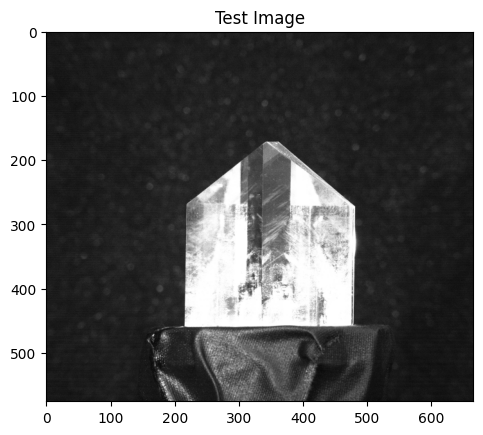

In [4]:
# Load the image
img = load_image(5)
h,w,_ = img.shape
print(f'Image Size: {w} x {h}')

# Show it
show_image('Test Image', img)

# Make the Mask (Matte)

In [12]:
def make_mask(img, threshold=50, maxVal=255):

    # Convert to grayscale
    #gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Apply a blur to the image
    #blur = cv.GaussianBlur(gray, (11,11), 0)

    # https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

    # Perform thresholding
    #ret, thresh = cv.threshold(blur, 0, 2**8, cv.THRESH_BINARY+cv.THRESH_OTSU)  # Otsu algorithm for optimal threshold value


    # Settings for the Sement Anything model
    # Options:  sam_vit_b_01ec64.pth, sam_vit_l_0b3195.pth, or sam_vit_h_4b8939.pth
    #checkpointPath = 'sam_vit_h_4b8939.pth'
    #modelType = 'vit_h'  # vit_b, vit_l, vit_h 
    checkpointPath = 'sam_vit_b_01ec64.pth'
    modelType = 'vit_b'

    # Create a segment-anything--model object
    sam = sam_model_registry[modelType](checkpoint=checkpointPath)

    # Track specific points on the image which are part of the object to be segmented (1) or not (0)
    pointList = []
    labelList = []


    # TODO:  The crystal might not be in the center in the real world.  This 
    #        is likely going to have to be based on the center of mass of a naive 
    #        thresholding approach, or something similar.
    #
    #        The same is true for the bounding box.


    # Define points on the image
    center_x = int(w/2)
    center_y = int(h/2)
    center = (center_x, center_y)
    pointList.append(center)

    # Define if the image is in the background (0), or the foreground (1)
    label = 1
    labelList.append(label)


    # Define specific points which are background (not the thing we care about)
    #pointList.append((int(w*0.1), int(h*0.1)))
    #labelList.append(0)

    #pointList.append((int(w*0.1), int(h*0.9)))
    #labelList.append(0)

    #pointList.append((int(w*0.9), int(h*0.1)))
    #labelList.append(0)

    #pointList.append((int(w*0.9), int(h*0.9)))
    #labelList.append(0)

    #pointList.append((int(w*0.5), int(h*0.9)))
    #labelList.append(0)

    # Convert lists to numpy arrays
    input_point = np.array(pointList)
    input_label = np.array(labelList)


    # Define the bounding box
    x1 = int(w * 0.20)
    x2 = int(w * 0.8)
    y1 = int(h * 0.2)
    y2 = int(h * 0.85)

    input_box = np.array([x1, y1, x2, y2])


    # Create a predictor object
    predictor = SamPredictor(sam)

    # Define the image the predictor will use
    predictor.set_image(img)

    #masks, _, _ = predictor.predict(<input_prompts>)
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        box=input_box,
        multimask_output=False,  # Set to true to output multiple options.
    )

    mask = masks[0]

    # Threshold the image to create a boolean mask image
    image2 = img.copy()
    image2[mask] = (255,255,255)
    image2[~mask] = (0,0,0)

    # Conver to grayscale
    gray = cv.cvtColor(image2, cv.COLOR_RGB2GRAY)

    return gray

Image Size: 666 x 576


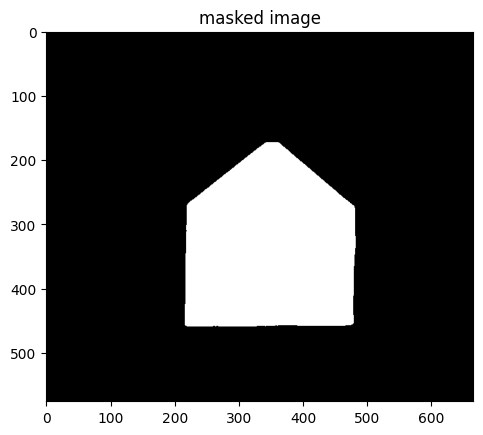

In [13]:
maskImg = make_mask(img)

h,w,_ = img.shape
print(f'Image Size: {w} x {h}')

show_image('masked image', maskImg)

# Use contour detection (boundary tracing) to get the perimeter

In [10]:
def get_boundary(img, showContours=True, plotTitle='contours'):
    # https://learnopencv.com/contour-detection-using-opencv-python-c/
    # https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0
    # https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga17ed9f5d79ae97bd4c7cf18403e1689a

    # TODO:  the findContours algorithm expects a white object on a black background...  May need to pre-proces for the generic / transparent cases.

    # detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
    contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_NONE)
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_EXTERNAL, method=cv.CHAIN_APPROX_NONE)
    
    # TODO: Try the simple algorithm, then fit lines in between the points to approximate...
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_SIMPLE)

    # This one is filtered... https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga4303f45752694956374734a03c54d5ff
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_TC89_L1)

    # This one is also filtered... https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga4303f45752694956374734a03c54d5ff
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_TC89_KCOS)



    # Find the biggest contour
    biggestIndex = None
    biggestSize = 0
    for i,c in enumerate(contours):
        if len(c) > biggestSize:
            biggestSize = len(c)
            biggestIndex = i

    contours = contours[biggestIndex]

    x = contours[:,0,0]
    y = contours[:,0,1]

    if showContours == True:
        # draw contours on the original image
        #image_copy = img.copy()
        #cv.drawContours(image=image_copy, contours=contours, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv.LINE_AA)
        #show_image('contours', image_copy)
        show_image(plotTitle, img)
        plt.plot(x, y, 'r.')


    h,w = img.shape


    # TODO:  This really should take into account the camera viewing angle. The big assumption here (which is OK in this case) is 
    #        that the center of the camera/lens is aligned with the center of the rotational stage.

    # center the x axis about 0
    x = np.array(x - w/2, dtype=int)    # This needs to be the center of rotation...
    
    # Invert the y axis
    y = h - y

    c = np.matrix((x, y)).T  # return x/y pairs

    # Remove redundant points
    #c = np.unique(c, axis=0)

    if showContours == True:
        fig2 = plt.figure()
        plt.plot(c[:,0], c[:,1], '.')
        plt.grid(True)
        plt.axis('image')
        plt.title('Contour Points')

    return np.matrix(c)

xDelta =265 (56.71 mm)
yDelta =286 (61.204 mm)


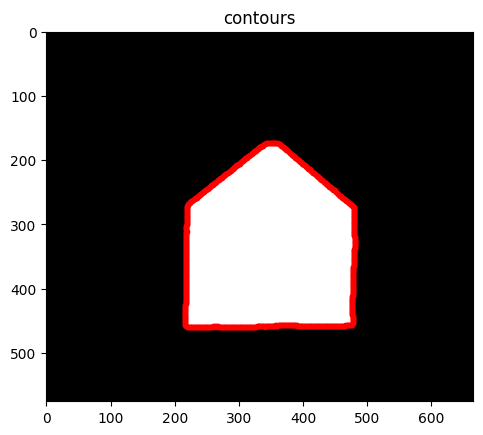

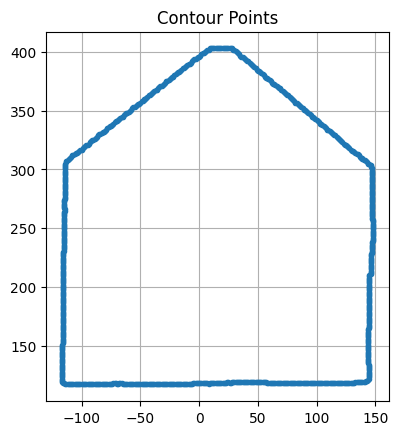

In [14]:
contours = get_boundary(maskImg, showContours=True)

x = contours[:,0]
y = contours[:,1]
xDelta = np.max(x) - np.min(x)
yDelta = np.max(y) - np.min(y)

print(f'{xDelta =} ({xDelta*0.214} mm)')
print(f'{yDelta =} ({yDelta*0.214} mm)')

# Test Contour Detection

Loading "real_crystal_ring_white_light/crystal_0010.jpg...


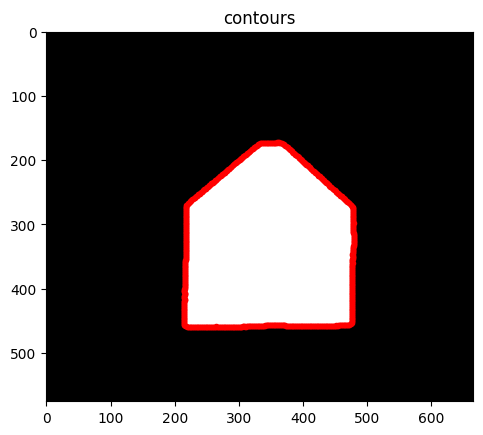

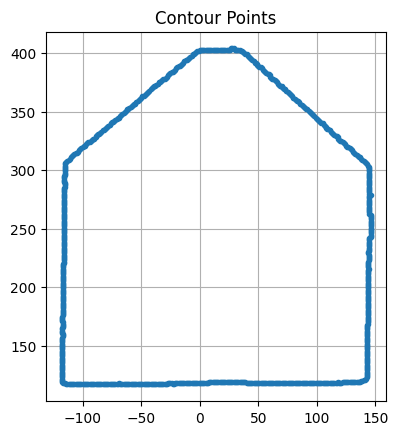

In [15]:
degree = 10

# Load the image
img = load_image(degree)
maskImg = make_mask(img)
contours = get_boundary(maskImg, showContours=True)

# Rotate 3D

In [16]:
def rotate_3d(coords,angle=0,axis=[0,1,0]):

    theta = angle * np.pi / 180.

    Rx = np.matrix([[1,                 0,                  0],
                    [0,                 np.cos(theta),      -np.sin(theta)],
                    [0,                 np.sin(theta),      np.cos(theta)]
                  ])

    Ry = np.matrix([[np.cos(theta),     0,                  np.sin(theta)],
                    [0,                 1,                  0],
                    [-np.sin(theta),    0,                  np.cos(theta)]
                  ])

    Rz = np.matrix([[np.cos(theta),     -np.sin(theta),     0],
                    [np.sin(theta),     np.cos(theta),      0],
                    [0,                 0,                  1]
                  ])

    # TODO: Support rotation along other axes...
    rotationMatrix = Ry


    if type(coords) == type([]):
      
      coords_rotated = []

      if len(coords) > 0:
        for c in coords:
          if np.shape(c)[1] > 0:
            cr = rotationMatrix * c.T
            coords_rotated.append(cr.T)

    else:
      coords_rotated = rotationMatrix * coords.T
      coords_rotated = coords_rotated.T

    return coords_rotated

In [17]:
def contour_to_3d(contour2d):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    #contours_3d = np.hstack((contour2d[:,0], zVect, contour2d[:,1]))
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    return contours_3d

# Create a 3D version of the contour through multiple depth planes

In [18]:
def contour_to_3d_with_depth(contour2d, zMin=-640, zMax=640, zStep=1):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    
    # Create the 3d vector
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    # Define the z coordinates
    #z = np.matrix(np.arange(zMin, zMax+zStep, zStep)).T
    z = np.arange(zMin, zMax+zStep, zStep)

    # Figure out how many elements we have in the z direction
    Nz = len(z)

    # Figure out how many elements we have in the contour
    Nxy = np.shape(contour2d)[0]

    # Replicate this stack
    contours_3d_deep = np.tile(contours_3d, (Nz, 1))

    # Add the z coordinates
    i = 0
    for iz in range(0, Nz):
        for ixy in range(0, Nxy):
            contours_3d_deep[i,2] = z[iz]
            i += 1

    return contours_3d_deep

Loading "real_crystal_ring_white_light/crystal_0000.jpg...


(0.0, 640.0)

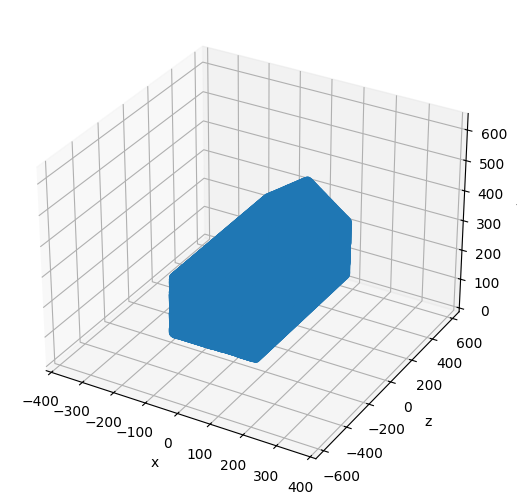

In [19]:
#print(contour_to_3d_with_depth(np.matrix([[0,0],[0,1],[0,2]]), -2, 2, 1))

# Load a test contour
img = load_image(0)
maskImg = make_mask(img)
contours = get_boundary(maskImg, showContours=False)
contours3d_deep = contour_to_3d_with_depth(contours, zMin=-400, zMax=400, zStep=10)


# Plot the two contours to check alignment
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(contours3d_deep[:,0], contours3d_deep[:,2], contours3d_deep[:,1], 'b.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)

# Test Contours

Loading "real_crystal_ring_white_light/crystal_0110.jpg...


(-97.1, 103.1, 102.65, 418.35)

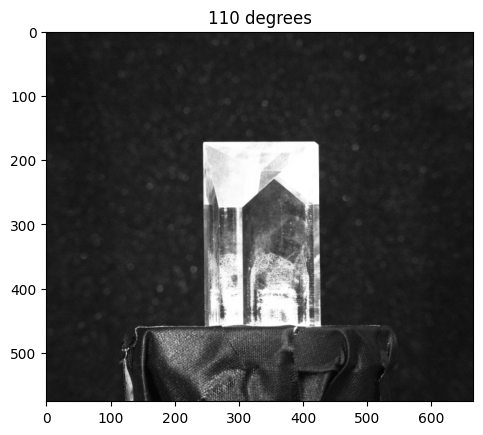

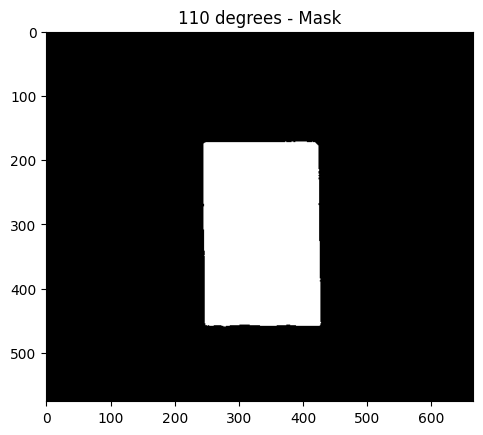

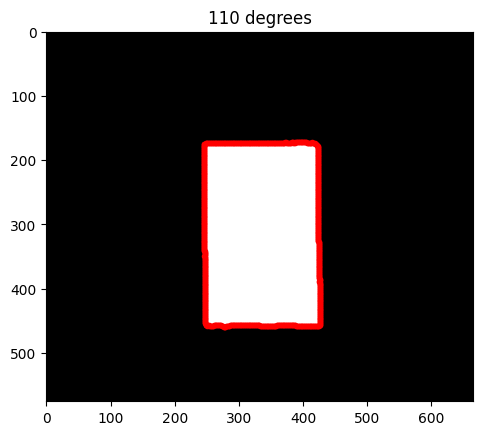

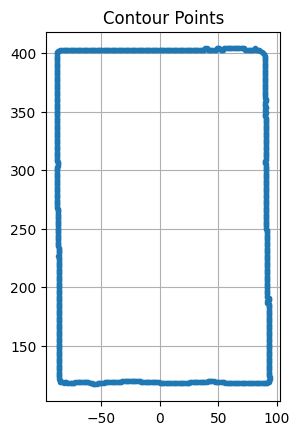

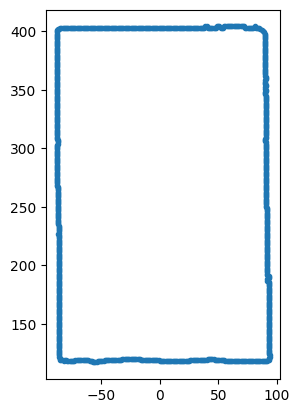

In [20]:

angle = 110

# Load the image
img = load_image(angle)

# Display the image
show_image(f'{angle} degrees', img)

# Create the mask / matte
maskImg = make_mask(img)

# Display the image
show_image(f'{angle} degrees - Mask', maskImg)

# Load the contours
contours = get_boundary(maskImg, showContours=True, plotTitle=f'{angle} degrees')


fig = plt.figure()
plt.plot(contours[:,0], contours[:,1], '.')
plt.axis('image')

# Michelangelo

In [21]:
def michelangelo(contour, block):
    '''
    Carve out the parts that aren't David. 
    
    Each rotated view carves out a section of the "block". In this way, we remove
    the parts that aren't associated with the object.

    NOTE: this carving operation is done from the camera's perspective (from the 
          camera viewing angle). To do this in a less constrained environment, the
          camera angle (relative to the object) needs to be determined.
    '''

    newBlock = []

    for pt in block:
        # determine if a point is inside, or outside, of the polygon formed by the contour vector
        x = pt[0, 0]
        y = pt[0, 1]
        z = pt[0, 2]
        #pt = (x, z)
        pt = (x, y)

        # https://docs.opencv.org/3.4.5/d3/dc0/group__imgproc__shape.html#ga1a539e8db2135af2566103705d7a5722
        result = cv.pointPolygonTest(contour, pt, measureDist=False)

        if result >= 0:
            newBlock.append((x, y, z))


    newBlock = np.matrix(newBlock)
    
    return newBlock

# Load the camera calibration (for pixel -> mm scaling)
https://docs.google.com/spreadsheets/d/1HlIQD8qF7d1AKRB1dQvAReDSbLFnypIe2-no22aY2lQ/edit#gid=0

In [22]:
def scale_coords(block, calibrationFilePath):

    # Load the camera calibration
    if os.path.exists(calibrationFilePath) == False:
        raise Exception(f'ERROR: could not find calibration file ({calibrationFilePath})')

    with open(calibrationFilePath, 'rb') as f:
        data = pickle.load(f)

    scaling = data['scalingFactor']   # mm / pixel

    scaling *= 0.88   # not from calibration directly, so this is suspicious.  This was from reconciling the 3D-printed model.

    print(f'Applying a scaling factor of {scaling} to the block...')

    # Apply the scaling factor (pixel coordinates --> real world (mm) coordinates)
    #block = float(scaling) * np.array(block, dtype=float)
    block *= scaling

    # Convert back to an int32
    #block = np.array(block, dtype=np.int32)

    return block

# Initialize the Block (deep bunnies)

In [23]:
w = int(resolution[0] * scaleFactor_default)
h = int(resolution[1] * scaleFactor_default)

#--------------------------------------------------
#  Initialize the block
#--------------------------------------------------
zMin = -w    # check these values
zMax = w     # check these values
zStep = zAxisStepSize
block = None

angleStep = 5
angleMax = 360

#--------------------------------------------------
#  Carve out bits of the block for each angle
#--------------------------------------------------
rotatedAngle = 0
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)

    # TODO: Undistort the image before processing. This requires the camera calibration...

    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)

    if block is not None:
        block = michelangelo(contours, block)
        
    b = contour_to_3d_with_depth(contours, zMin, zMax, zStep)
    if block is None:
        block = b.copy()
    else:
        block = np.vstack((block, b))
    
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


if abs(rotatedAngle) == 360:
    rotatedAngle = 0
else:
    block = rotate_3d(block, -rotatedAngle)
    rotatedAngle = 0


# Take a second pass to carve out unneeded points
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)

    # TODO: Undistort the image before processing. This requires the camera calibration...

    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)

    print(f'Cutting at angle {rotatedAngle}...')

    block = michelangelo(contours, block)
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


#--------------------------------------------------
#  Make sure the block sits at 0 (not an offset)
#--------------------------------------------------
block[:,1] -= np.min(block[:,1])


Loading "real_crystal_ring_white_light/crystal_0000.jpg...
Loading "real_crystal_ring_white_light/crystal_0005.jpg...
Loading "real_crystal_ring_white_light/crystal_0010.jpg...
Loading "real_crystal_ring_white_light/crystal_0015.jpg...
Loading "real_crystal_ring_white_light/crystal_0020.jpg...
Loading "real_crystal_ring_white_light/crystal_0025.jpg...
Loading "real_crystal_ring_white_light/crystal_0030.jpg...
Loading "real_crystal_ring_white_light/crystal_0035.jpg...
Loading "real_crystal_ring_white_light/crystal_0040.jpg...
Loading "real_crystal_ring_white_light/crystal_0045.jpg...
Loading "real_crystal_ring_white_light/crystal_0050.jpg...
Loading "real_crystal_ring_white_light/crystal_0055.jpg...
Loading "real_crystal_ring_white_light/crystal_0060.jpg...
Loading "real_crystal_ring_white_light/crystal_0065.jpg...
Loading "real_crystal_ring_white_light/crystal_0070.jpg...
Loading "real_crystal_ring_white_light/crystal_0075.jpg...
Loading "real_crystal_ring_white_light/crystal_0080.jpg.

Applying a scaling factor of 0.18896322001244875 to the block...
x values: [[-21.7307703]], [[23.43143928]]
y values: [[0.]], [[52.34281194]]
z values: [[-13.80324816]], [[17.39406091]]


Text(0.5, 0, 'y')

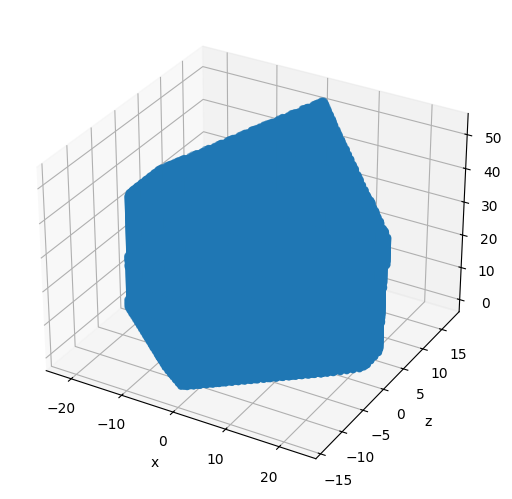

In [27]:
scaledBlock = copy.deepcopy(block)

#-----------------------------------------------------------
#  Scale the coordinates to be in millimeters not in pixels
#-----------------------------------------------------------
scaledBlock = scale_coords(scaledBlock, calibrationFilePath)


#--------------------------------------------------
#  Write the data to a file
#--------------------------------------------------
# Write to an ASC (point cloud) file
pointCloudFileName = '%s-z=%d,s=%.3f.asc' % (imageFolderPath, zStep, scaleFactor_default)
file = open(pointCloudFileName, 'w')
for pt in scaledBlock:
    pt.tofile(file, sep=' ', format='%.6f')
    file.write('\n')
file.close()


#--------------------------------------------------
#  Plot the results
#--------------------------------------------------
# Get the individual x/y/z values
x = scaledBlock[:,0]
y = scaledBlock[:,1]
z = scaledBlock[:,2]

print(f'x values: {min(x)}, {max(x)}')
print(f'y values: {min(y)}, {max(y)}')
print(f'z values: {min(z)}, {max(z)}')

# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

ax.scatter(x, z, y, 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

#ax.set_xlim3d(-400, 400)
#ax.set_ylim3d(-640, 640)
#ax.set_zlim3d(0,640)

In [25]:
block_pv = pv.wrap(scaledBlock)
dargs = dict(show_edges=True)
p = pv.Plotter()
p.add_mesh(block_pv, color='r', point_size=3.0, render_points_as_spheres=True)
p.show()

Widget(value="<iframe src='http://localhost:55625/index.html?ui=P_0x17ad9fb7ac0_0&reconnect=auto' style='width…

# Create a surface

In [28]:
pointCloud = np.array(pd.read_csv(pointCloudFileName, delimiter=' ', header=None)) 

# Using Open3D - Calculate Normals

In [29]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pointCloud)
#o3d.visualization.draw_geometries([pcd])

pcd.compute_convex_hull()
pcd.remove_duplicated_points()
pcd.estimate_normals(fast_normal_computation=False)
#pcd.orient_normals_consistent_tangent_plane(10)

# Process the normals and make sure they are all pointing the correct direction
normals = np.asarray(pcd.normals)
points = np.asarray(pcd.points)
center = pcd.get_center()
N = len(points)

# Create a color vector to help highlight issues  (colors are r,g,b between 0 and 1)
colors = np.matrix(np.ones((N, 3))) * 0.3   # (0.3, 0.3, 0.3) = gray

# Create a vector from the center of mass to the point
v = points - center

for i in range(0, N):
    dp = np.dot(v[i, :], normals[i, :])
    if dp < 0:
        normals[i,:] *= -1
        #colors[i,:] = np.array([1,0,0])

# Save the normals back to the point cloud
pcd.normals = o3d.utility.Vector3dVector(normals)
#pcd.colors = o3d.utility.Vector3dVector(colors)


# Visualize the point cloud and normals

In [30]:
visualizeNormals = False

if visualizeNormals == True:
    # https://stackoverflow.com/questions/58971041/is-it-possible-to-show-normal-on-the-mesh-surface-by-using-open3d
    # ctrl + 9 - renders the normals
    # pressing "n" allows normals to be visualized
    vis = o3d.visualization.Visualizer()
    vis.create_window()
    vis.add_geometry(pcd)
    #vis.get_render_option().mesh_color_option = MeshColorOption.Normal
    vis.run()
    vis.destroy_window()

# Create a Mesh from the Point Cloud

In [31]:
visualizeMesh = True

# http://www.open3d.org/docs/latest/tutorial/Advanced/surface_reconstruction.html
'''
#tetra_mesh, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcd)
zGapSize = 20
alpha = zGapSize * 100
#mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha, tetra_mesh, pt_map)
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)
mesh.compute_vertex_normals()
mesh.remove_degenerate_triangles()
#check_properties('Pseudo Crystal', mesh)
o3d.visualization.draw_geometries([mesh], mesh_show_back_face=False)
'''


# Poisson reconstruction
# https://stackoverflow.com/questions/68777480/struggling-to-create-watertight-meshes-out-of-point-cloud-data-using-open3d-in-p
# http://www.open3d.org/docs/latest/python_api/open3d.geometry.TriangleMesh.html?highlight=create_from_point_cloud_poisson#open3d.geometry.TriangleMesh.create_from_point_cloud_poisson

tStart = time.time()
mesh,densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=12, width=0, scale=1.1, linear_fit=True)
#mesh,densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=8, linear_fit=True)
mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.5, 0.5, 0.5])
mesh.remove_degenerate_triangles()

tStop = time.time()
tTotal = tStop - tStart
print(f'Poisson reconstruction time: {tTotal} seconds')

if visualizeMesh == True:
    o3d.visualization.draw_geometries([mesh], mesh_show_back_face=False)

# Ball pivoting 
'''
zGapSize = 20
alpha = [zGapSize, zGapSize * 2]
alpha = o3d.utility.DoubleVector(alpha)
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, alpha)
o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)
'''

Poisson reconstruction time: 5.356756687164307 seconds


'\nzGapSize = 20\nalpha = [zGapSize, zGapSize * 2]\nalpha = o3d.utility.DoubleVector(alpha)\nmesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, alpha)\no3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)\n'

# Write to file

In [33]:
meshOutputFile = os.path.splitext(pointCloudFileName)[0] + '_mesh.ply'
o3d.io.write_triangle_mesh(meshOutputFile, mesh)

True

# Repair the mesh

In [38]:
repairMesh = True

if repairMesh == True:
    meshToFix = mesh
    #meshToFix = meshTriangulated

    # create the triangular mesh with the vertices and faces from open3d
    #tri_mesh = trimesh.Trimesh(np.asarray(meshToFix.vertices), np.asarray(meshToFix.triangles), vertex_normals=np.asarray(meshToFix.vertex_normals))
    tri_mesh = trimesh.load(meshOutputFile, force='mesh')

    tri_mesh.fix_normals()
    tri_mesh.fill_holes()
    trimesh.convex.is_convex(tri_mesh)

    outputFile = os.path.splitext(pointCloudFileName)[0] + '_trimesh_fixed.ply'

    trimesh.exchange.export.export_mesh(tri_mesh, outputFile)

    print('Watertight? ', tri_mesh.is_watertight)
    print('Volume: ', tri_mesh.volume)
    print('Surface Area: ', tri_mesh.area)  # https://trimesh.org/trimesh.html#trimesh.Trimesh.area
    print('Convex hull volume: ', tri_mesh.convex_hull.volume)

Watertight?  True
Volume:  37694.700465343194
Surface Area:  6665.722792940134
Convex hull volume:  38390.016812620495
